# Part 1 — Load and Inspect Audio Files

In this section we:

1. Load all speech files from the `Data-HW1/` directory.

Files:
- en-clean.wav
- en-noisy.wav
- fa-clean.wav
- fa-noisy.wav

2. Read:
- Sample rate
- Signal length
- Duration

3. Normalize the signals if needed.

4. Plot waveform of each audio file to visually inspect:
- speech regions
- silence regions
- possible noise patterns

This step is important before implementing Voice Activity Detection (VAD), because
understanding the characteristics of the signals helps later when choosing:
- frame size
- energy thresholds
- ZCR thresholds

d:\Uni\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


en-clean.wav
 Sample Rate: 16000 Hz
 Samples: 50176
 Duration: 3.14 sec

en-noisy.wav
 Sample Rate: 16000 Hz
 Samples: 50176
 Duration: 3.14 sec

fa-clean.wav
 Sample Rate: 16000 Hz
 Samples: 41261
 Duration: 2.58 sec

fa-noisy.wav
 Sample Rate: 16000 Hz
 Samples: 41261
 Duration: 2.58 sec



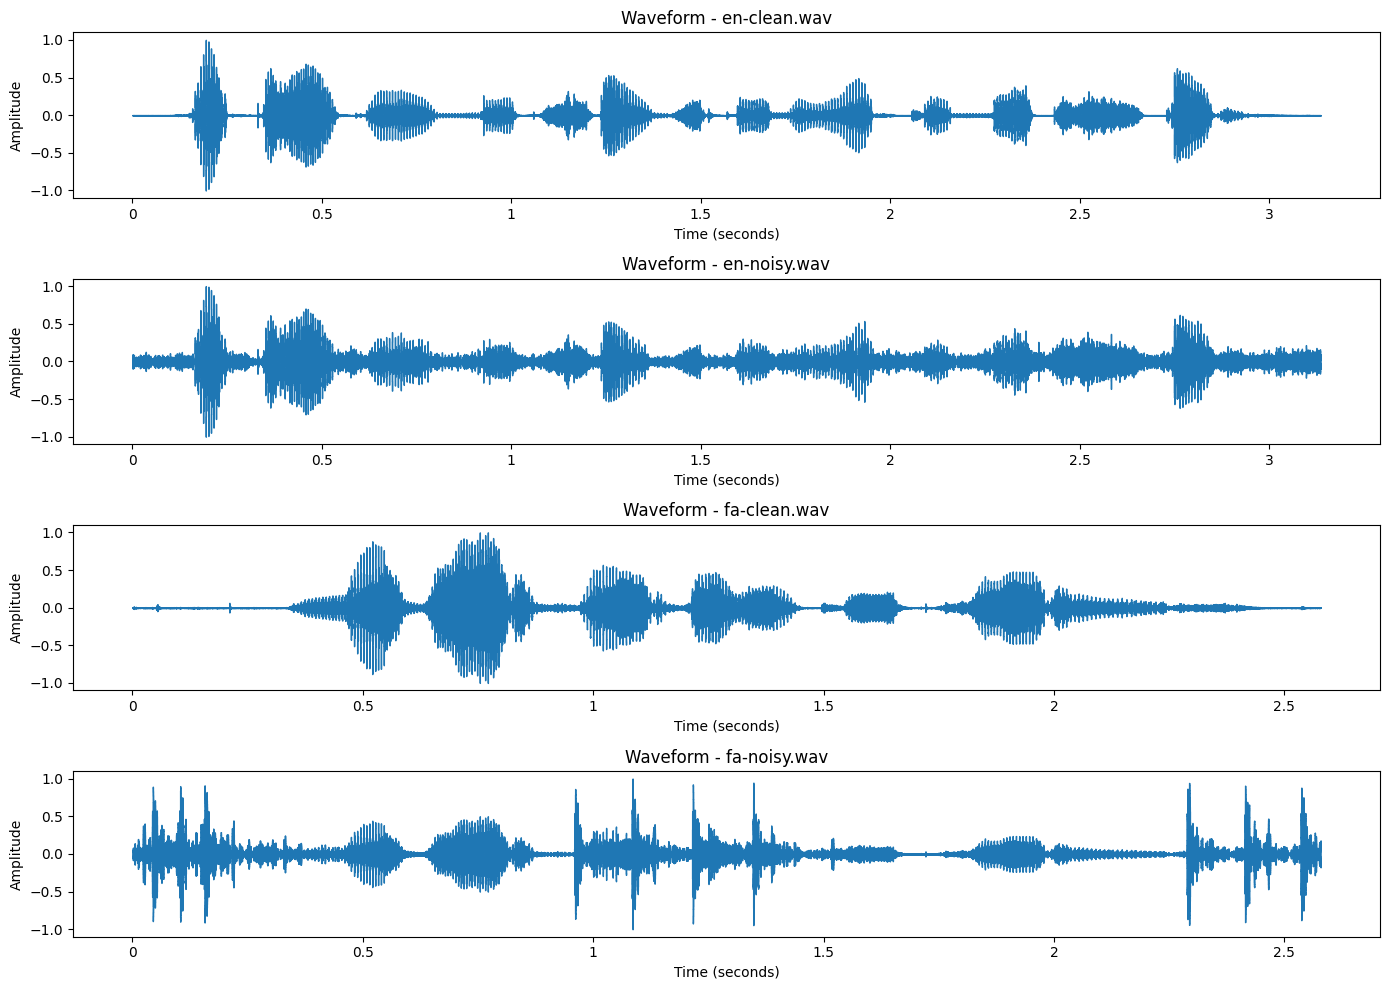

In [2]:
# =========================
# Part 1 - Audio Loading
# =========================

import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Directory containing homework audio files
DATA_DIR = "Data-HW1"

# List of audio files
audio_files = [
    "en-clean.wav",
    "en-noisy.wav",
    "fa-clean.wav",
    "fa-noisy.wav"
]

# Dictionary to store loaded signals
audio_data = {}

def load_audio(file_path):
    """
    Load an audio file.
    
    Returns:
        signal : numpy array
        sr     : sampling rate
    """
    
    # sr=None preserves original sample rate
    signal, sr = librosa.load(file_path, sr=None)
    
    # Normalize amplitude to [-1,1]
    signal = signal / np.max(np.abs(signal))
    
    return signal, sr


# -------------------------
# Load all signals
# -------------------------

for file_name in audio_files:
    
    path = os.path.join(DATA_DIR, file_name)
    
    signal, sr = load_audio(path)
    
    duration = len(signal) / sr
    
    audio_data[file_name] = {
        "signal": signal,
        "sr": sr,
        "duration": duration
    }
    
    print(f"{file_name}")
    print(f" Sample Rate: {sr} Hz")
    print(f" Samples: {len(signal)}")
    print(f" Duration: {duration:.2f} sec\n")


# -------------------------
# Plot waveforms
# -------------------------

plt.figure(figsize=(14,10))

for i, file_name in enumerate(audio_files,1):
    
    signal = audio_data[file_name]["signal"]
    sr = audio_data[file_name]["sr"]
    
    plt.subplot(len(audio_files),1,i)
    
    librosa.display.waveshow(
        signal,
        sr=sr
    )
    
    plt.title(f"Waveform - {file_name}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    
plt.tight_layout()
plt.show()

# Part 2 — Frame Blocking and Short-Time Energy Extraction

In this section we divide each audio signal into short overlapping frames.

Why framing?

Speech is non-stationary globally, but approximately stationary in short intervals
(typically 20–30 milliseconds), so features are extracted per frame.

Steps:

1. Split each signal into frames
   - Frame length: 25 ms
   - Frame shift (hop): 10 ms

2. Compute Short-Time Energy (STE) for every frame:

E = sum(x[n]^2)

3. Plot:
- waveform
- frame energy contour

Goal:
Energy should help distinguish:
- speech segments (higher energy)
- silence / non-speech (lower energy)

This is the first feature used for Voice Activity Detection.

en-clean.wav -> 312 frames
en-noisy.wav -> 312 frames
fa-clean.wav -> 256 frames
fa-noisy.wav -> 256 frames


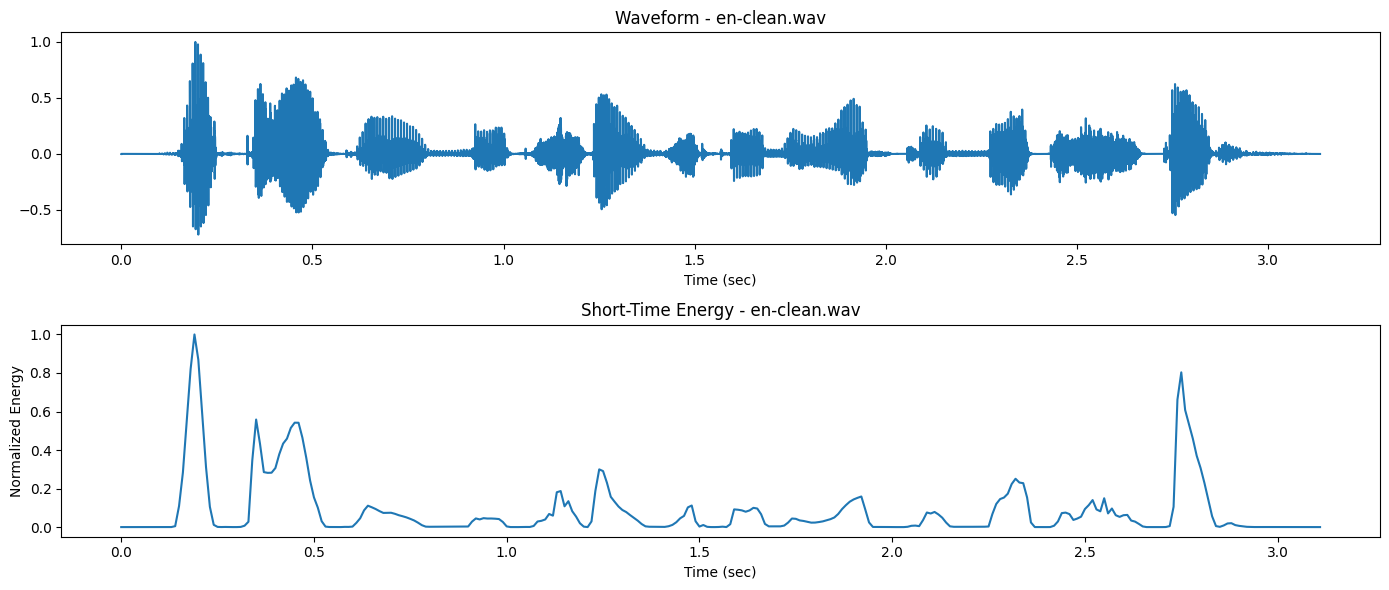

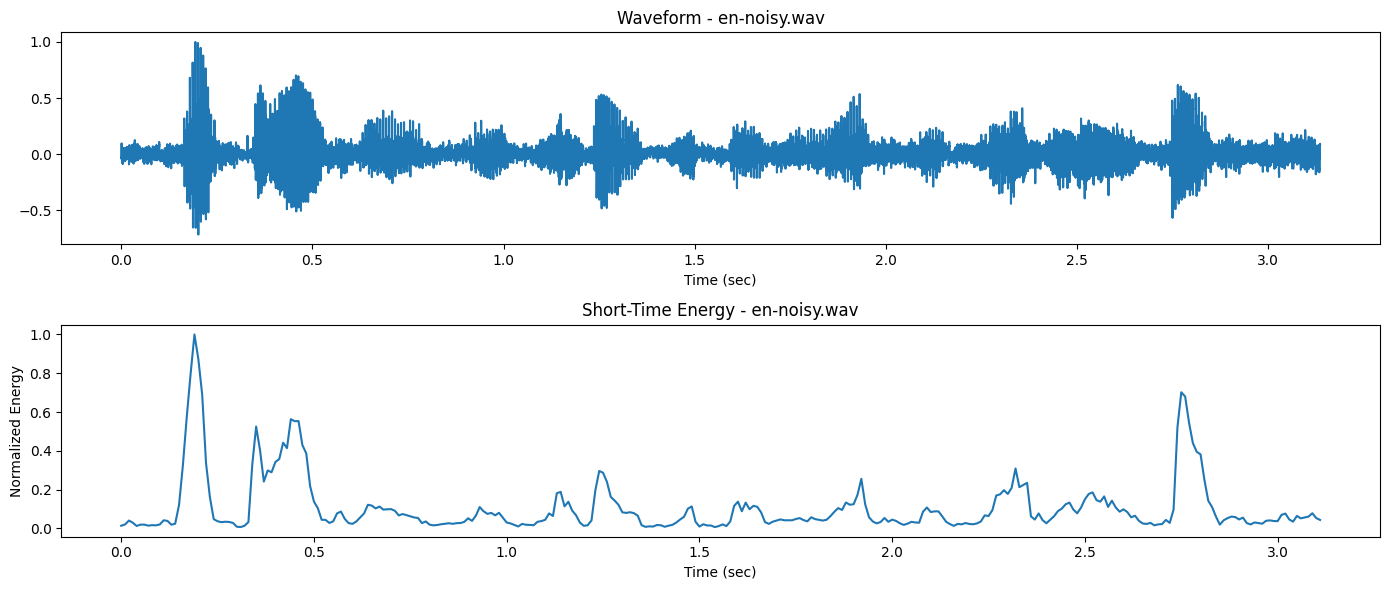

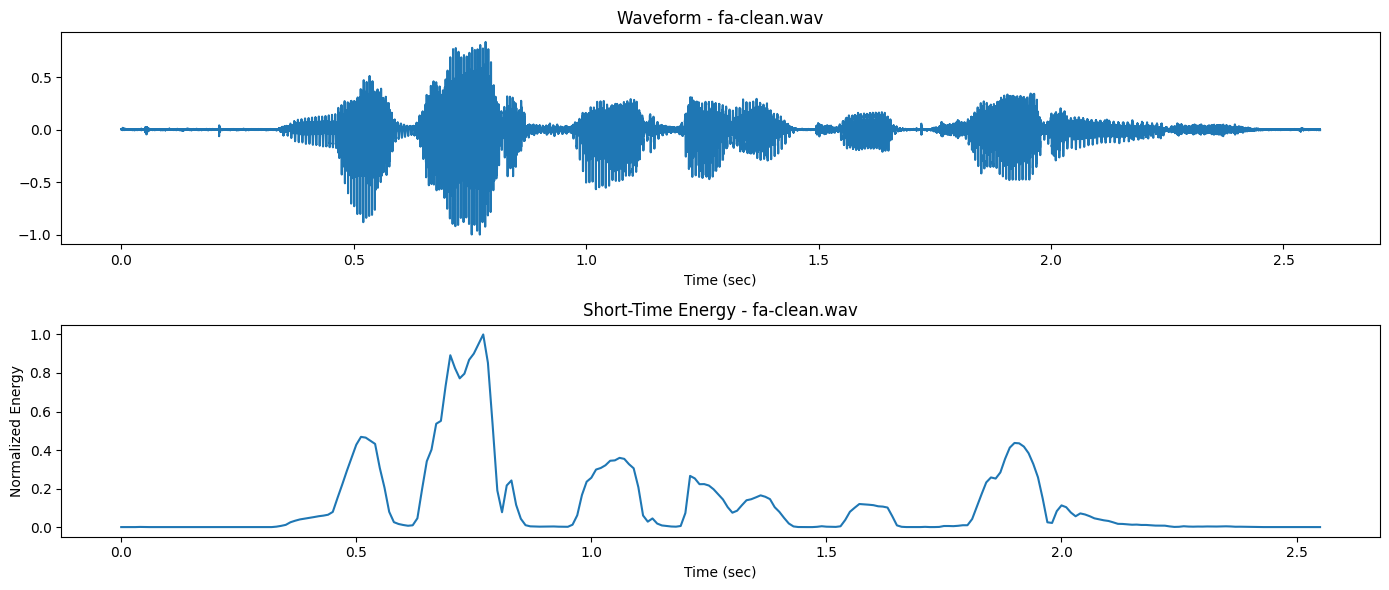

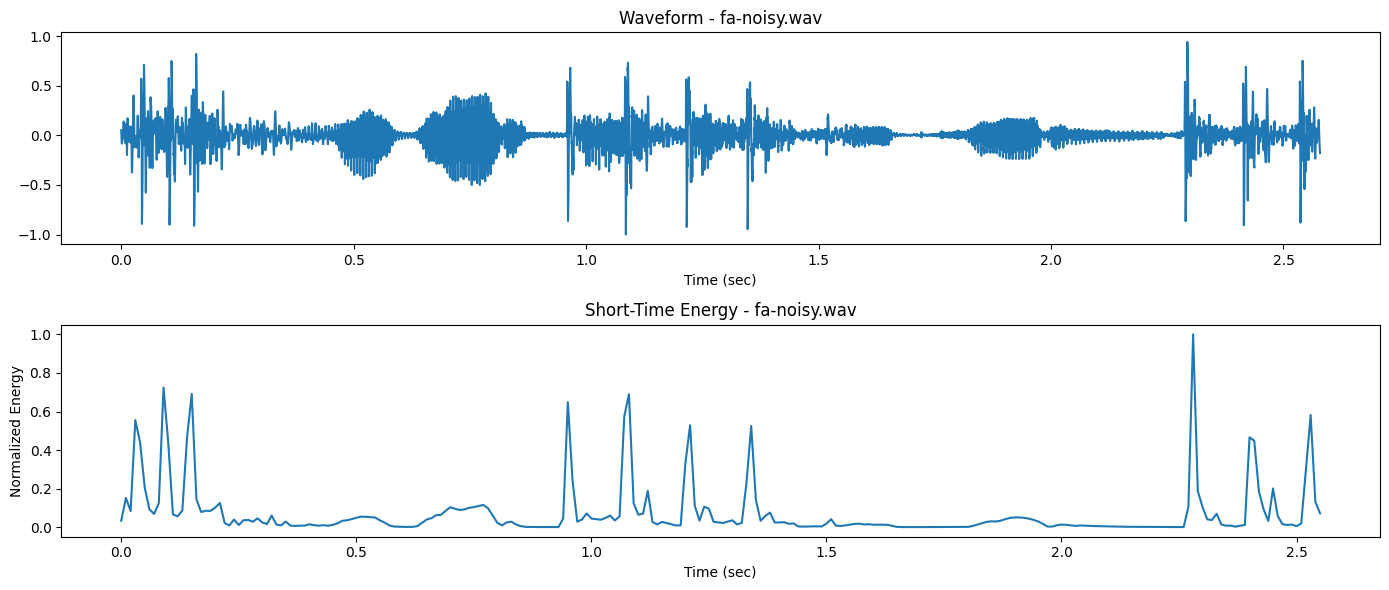

In [3]:
# ==================================
# Part 2 - Framing and Energy
# ==================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Framing parameters
# -----------------------------

FRAME_SIZE_MS = 25
HOP_SIZE_MS   = 10


def frame_signal(signal, sr,
                 frame_ms=25,
                 hop_ms=10):
    """
    Split signal into overlapping frames.
    
    Returns:
        frames -> shape (num_frames, frame_length)
    """

    frame_len = int(sr * frame_ms / 1000)
    hop_len   = int(sr * hop_ms / 1000)

    frames = []

    for start in range(
            0,
            len(signal)-frame_len,
            hop_len):

        frame = signal[start:start+frame_len]

        # Optional Hamming window
        frame = frame * np.hamming(frame_len)

        frames.append(frame)

    return np.array(frames)


def compute_short_time_energy(frames):
    """
    Compute energy for every frame.
    """
    
    # Sum of squared samples
    energy = np.sum(frames**2, axis=1)

    return energy


# -------------------------------------
# Process all files
# -------------------------------------

energy_results = {}

for file_name, data in audio_data.items():

    signal = data["signal"]
    sr     = data["sr"]

    frames = frame_signal(
        signal,
        sr,
        FRAME_SIZE_MS,
        HOP_SIZE_MS
    )

    energy = compute_short_time_energy(frames)

    # Normalize energy for easier thresholding later
    energy = energy / np.max(energy)

    energy_results[file_name] = {
        "frames": frames,
        "energy": energy
    }

    print(
        f"{file_name} -> "
        f"{len(frames)} frames"
    )


# -------------------------------------
# Visualize energy
# -------------------------------------

for file_name in audio_files:

    signal = audio_data[file_name]["signal"]
    sr     = audio_data[file_name]["sr"]

    energy = energy_results[file_name]["energy"]

    # time axis for signal
    t_signal = np.arange(len(signal))/sr

    # time axis for frame energy
    hop_len = int(sr*HOP_SIZE_MS/1000)
    t_energy = np.arange(len(energy))*hop_len/sr


    plt.figure(figsize=(14,6))

    # Waveform
    plt.subplot(2,1,1)
    plt.plot(
        t_signal,
        signal
    )
    plt.title(
        f"Waveform - {file_name}"
    )
    plt.xlabel("Time (sec)")


    # Energy contour
    plt.subplot(2,1,2)
    plt.plot(
        t_energy,
        energy
    )
    plt.title(
        f"Short-Time Energy - {file_name}"
    )
    plt.xlabel("Time (sec)")
    plt.ylabel("Normalized Energy")

    plt.tight_layout()
    plt.show()

# Part 3 — Zero Crossing Rate (ZCR) Extraction

In this section we compute the second feature used for Voice Activity Detection:
Zero Crossing Rate (ZCR).

Definition:

ZCR measures how often the signal changes sign
(positive to negative or negative to positive)
within each frame.

Why use ZCR?

Energy alone is often insufficient in noisy conditions.

ZCR helps distinguish:

- voiced speech:
  lower ZCR

- unvoiced sounds:
  higher ZCR

- many noise signals:
  often high ZCR

Steps:

1. Compute ZCR for every frame.

2. Normalize the values.

3. Plot:
- Short-Time Energy
- ZCR

4. Compare how both features behave for:
- clean speech
- noisy speech

These two features will later be combined for VAD decisions.

en-clean.wav -> 312 ZCR values extracted
en-noisy.wav -> 312 ZCR values extracted
fa-clean.wav -> 256 ZCR values extracted
fa-noisy.wav -> 256 ZCR values extracted


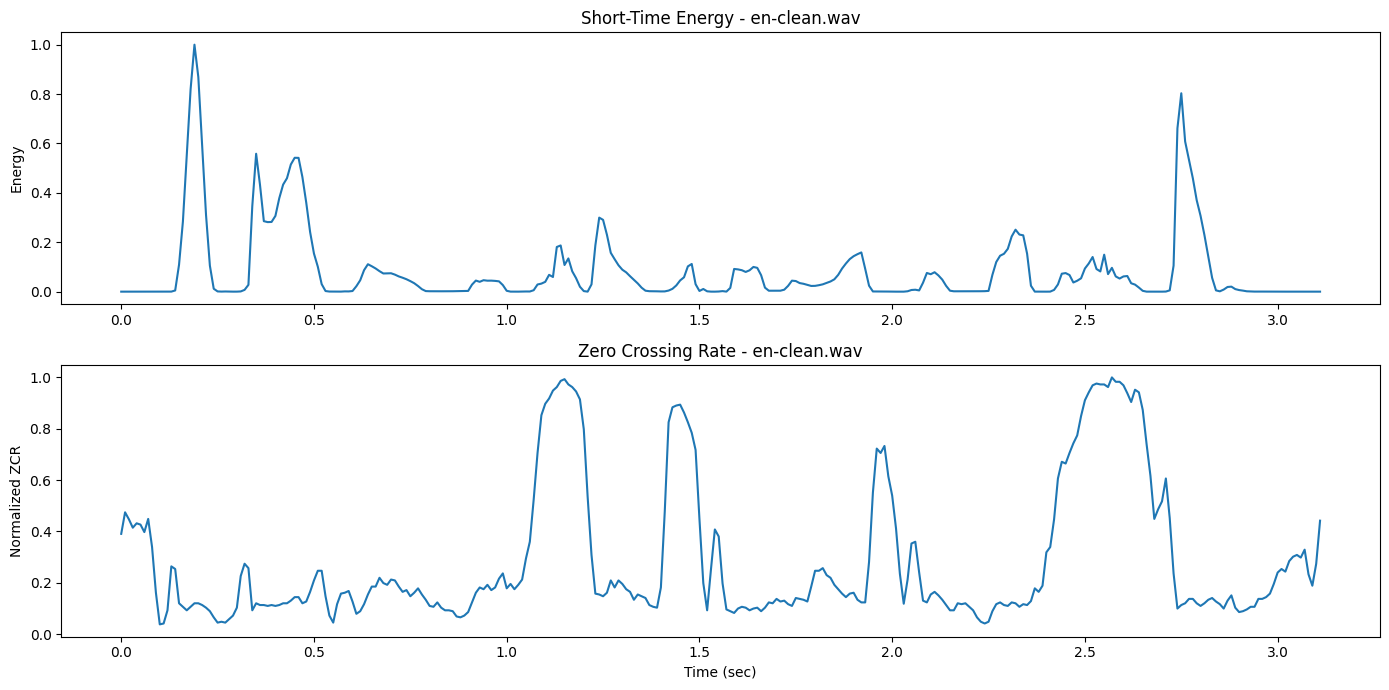

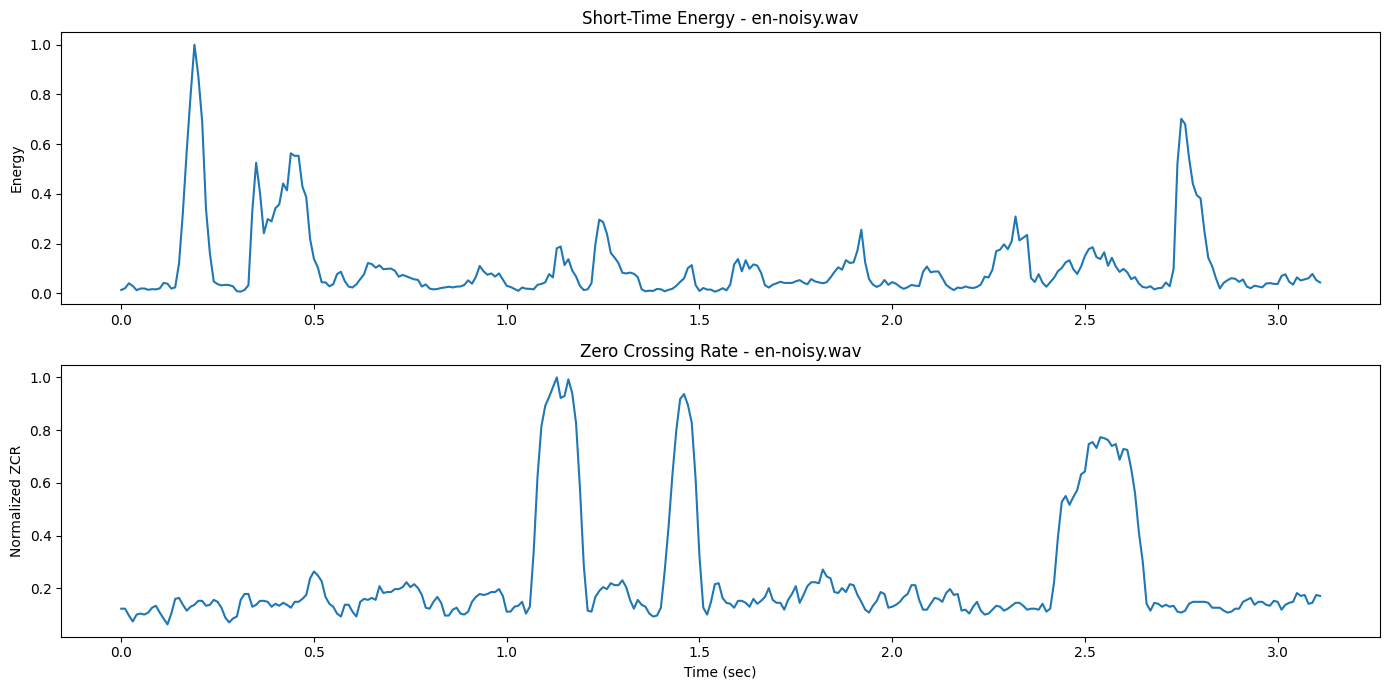

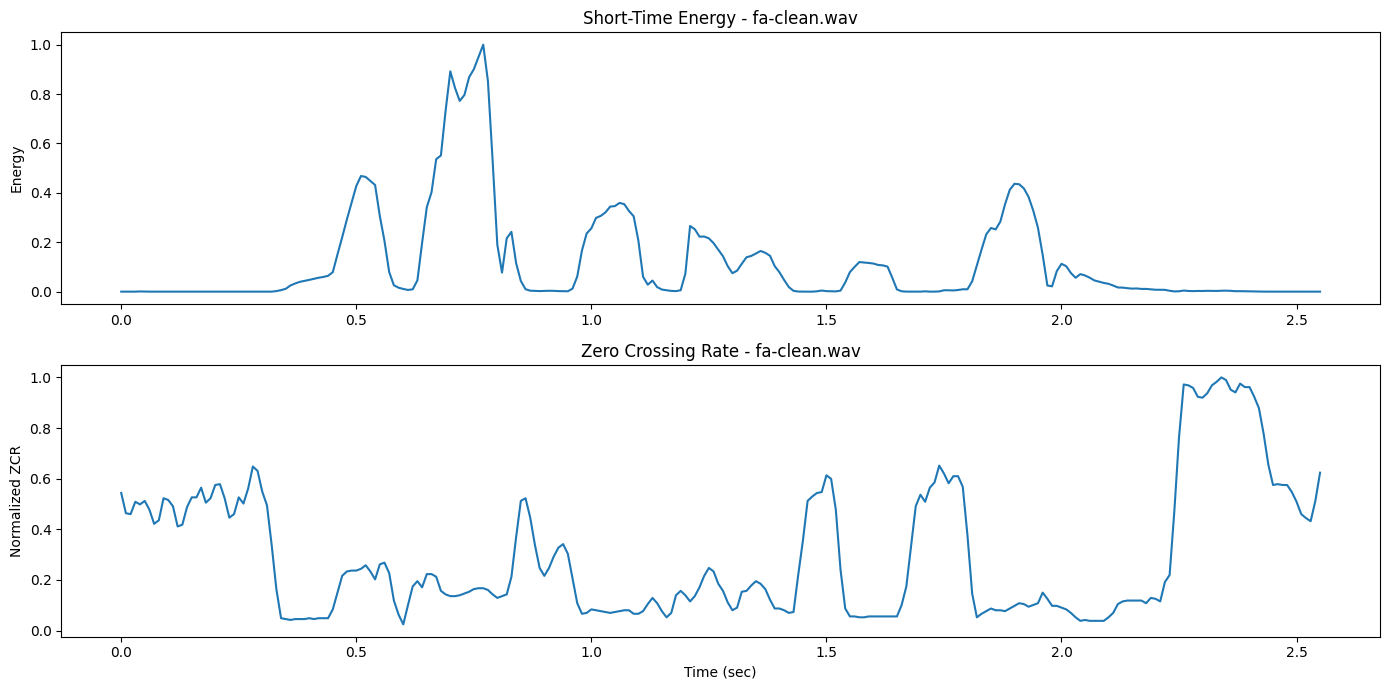

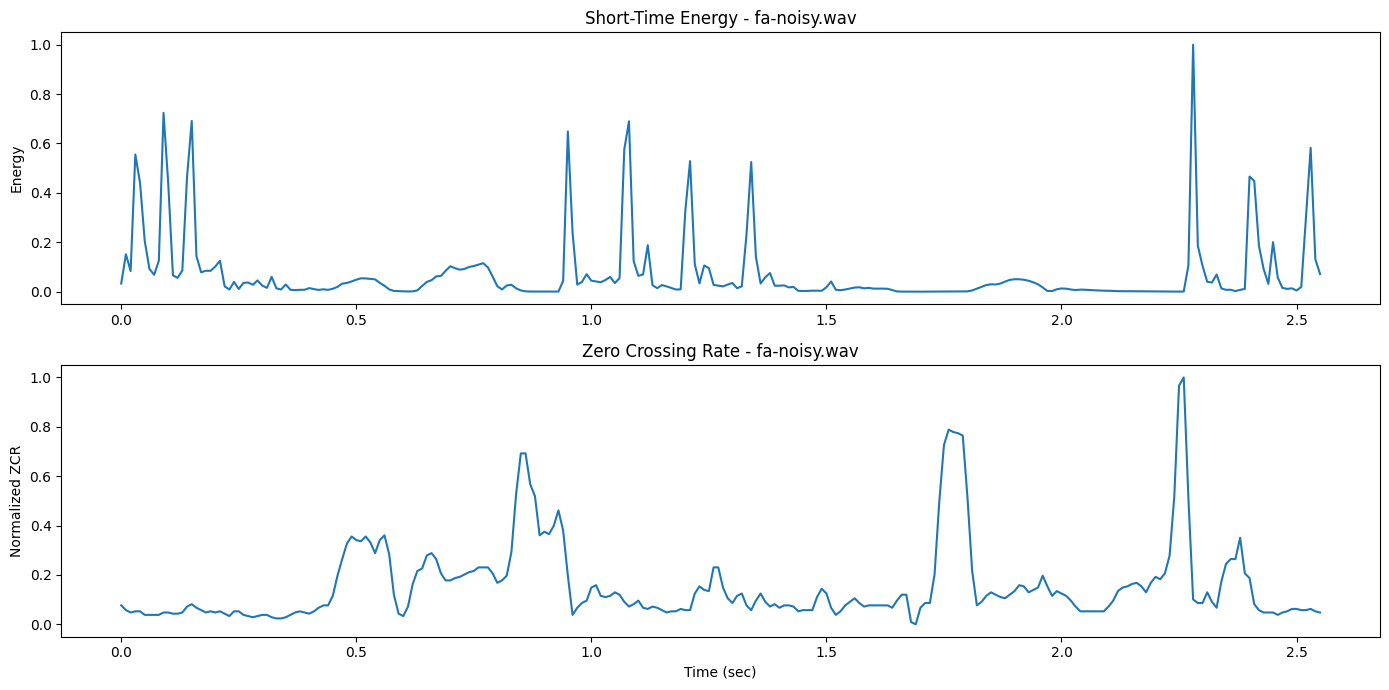

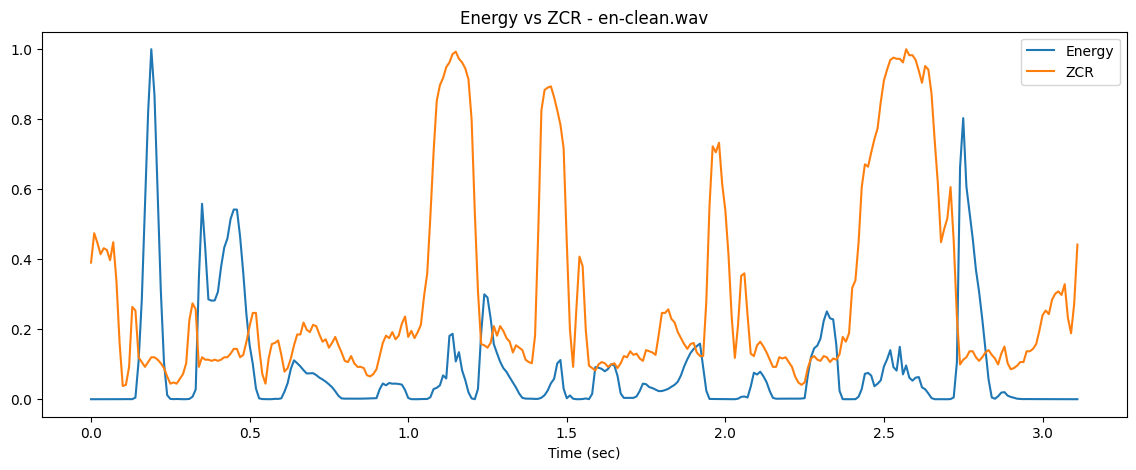

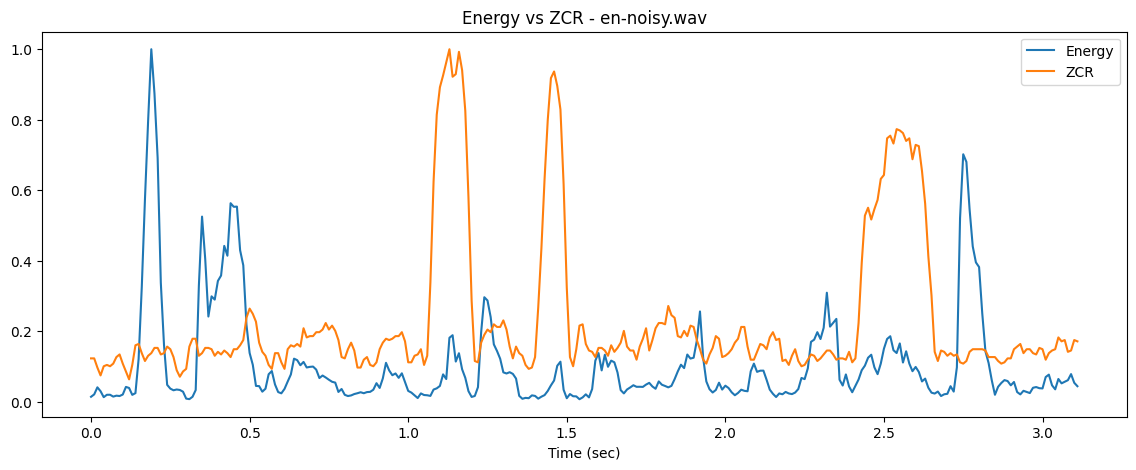

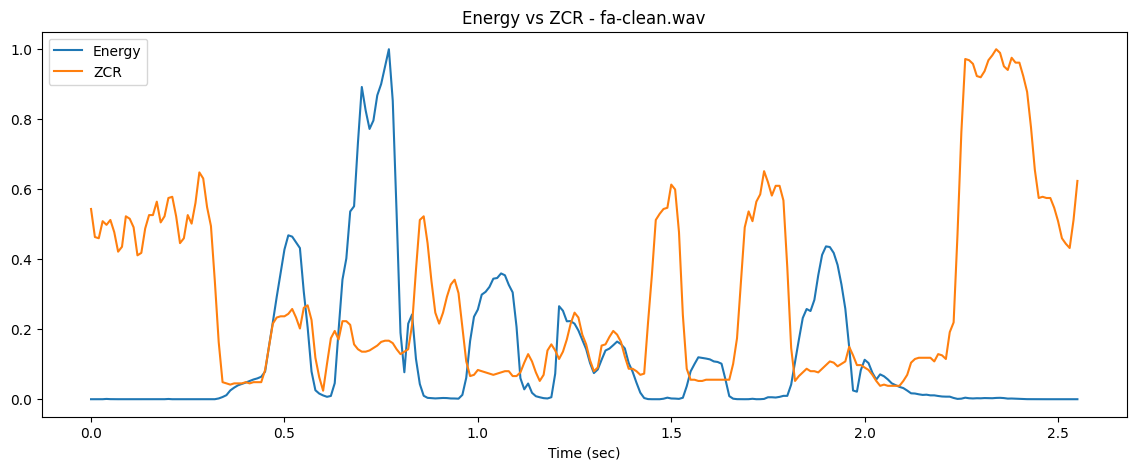

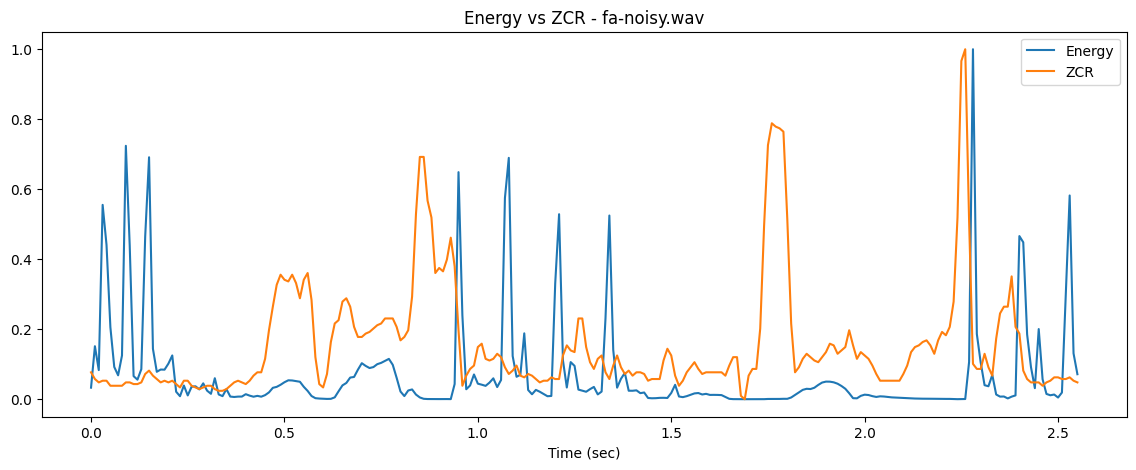

In [4]:
# ==================================
# Part 3 - Zero Crossing Rate
# ==================================

import numpy as np
import matplotlib.pyplot as plt


def compute_zcr(frames):
    """
    Compute zero crossing rate
    for every frame.
    
    Returns:
        zcr values per frame
    """

    zcr_values = []

    for frame in frames:

        # Count sign changes
        crossings = np.sum(
            np.abs(
                np.diff(
                    np.sign(frame)
                )
            )
        ) / 2

        # Normalize by frame length
        zcr = crossings / len(frame)

        zcr_values.append(zcr)

    return np.array(zcr_values)


# ---------------------------------
# Compute ZCR for all files
# ---------------------------------

for file_name in audio_files:

    frames = energy_results[file_name]["frames"]

    zcr = compute_zcr(frames)

    # Normalize for visualization
    zcr = zcr / np.max(zcr)

    energy_results[file_name]["zcr"] = zcr

    print(
        f"{file_name} -> "
        f"{len(zcr)} ZCR values extracted"
    )


# ---------------------------------
# Plot Energy and ZCR together
# ---------------------------------

for file_name in audio_files:

    energy = energy_results[file_name]["energy"]
    zcr    = energy_results[file_name]["zcr"]

    sr = audio_data[file_name]["sr"]
    hop_len = int(sr*HOP_SIZE_MS/1000)

    t = np.arange(len(energy))*hop_len/sr


    plt.figure(figsize=(14,7))


    # Energy
    plt.subplot(2,1,1)
    plt.plot(
        t,
        energy
    )
    plt.title(
        f"Short-Time Energy - {file_name}"
    )
    plt.ylabel("Energy")


    # ZCR
    plt.subplot(2,1,2)
    plt.plot(
        t,
        zcr
    )
    plt.title(
        f"Zero Crossing Rate - {file_name}"
    )
    plt.ylabel("Normalized ZCR")
    plt.xlabel("Time (sec)")


    plt.tight_layout()
    plt.show()


# ---------------------------------
# Overlay comparison
# ---------------------------------

for file_name in audio_files:

    energy = energy_results[file_name]["energy"]
    zcr    = energy_results[file_name]["zcr"]

    sr = audio_data[file_name]["sr"]
    hop_len = int(sr*HOP_SIZE_MS/1000)

    t = np.arange(len(energy))*hop_len/sr

    plt.figure(figsize=(14,5))

    plt.plot(
        t,
        energy,
        label="Energy"
    )

    plt.plot(
        t,
        zcr,
        label="ZCR"
    )

    plt.title(
        f"Energy vs ZCR - {file_name}"
    )

    plt.xlabel("Time (sec)")
    plt.legend()
    plt.show()

# Part 4 — Voice Activity Detection using Thresholds

In this section we detect speech and non-speech regions using thresholding.

Three approaches are tested:

1. Energy-only VAD
Speech if:
Energy > threshold

2. ZCR-only VAD
Speech if:
ZCR < threshold

3. Combined VAD
Speech if:
Energy > threshold_energy
AND
ZCR < threshold_zcr

Thresholds are selected empirically
(using signal inspection and trial-and-error).

Outputs:

- Binary speech/non-speech decision per frame
- Speech regions highlighted over waveform

This is the actual VAD segmentation stage.

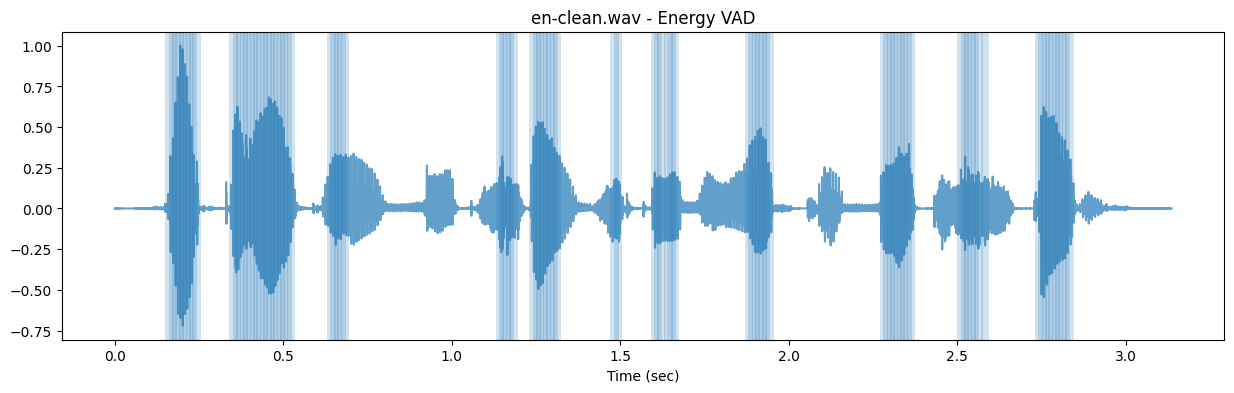

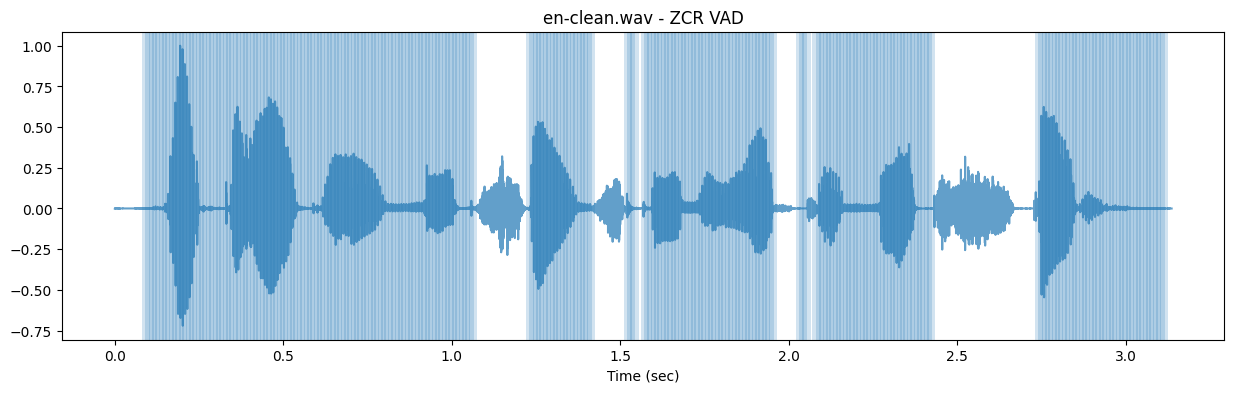

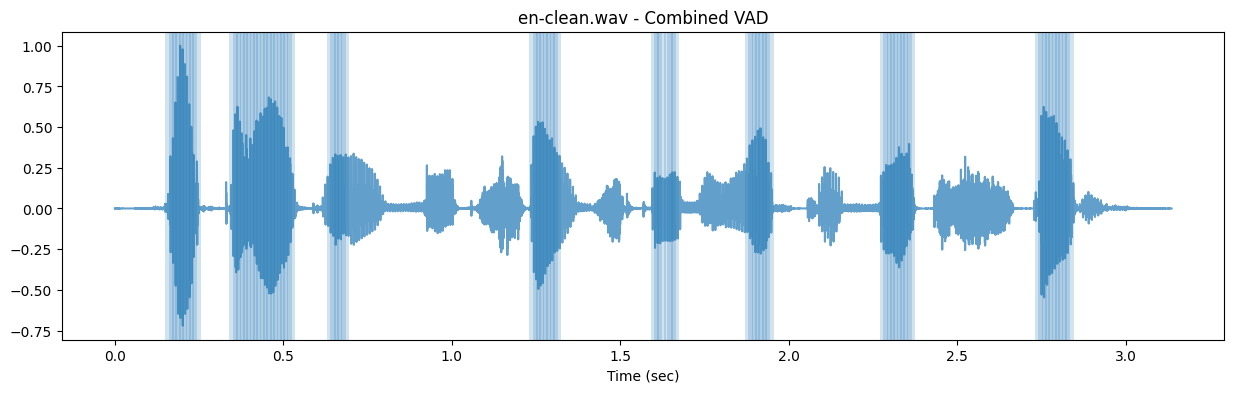

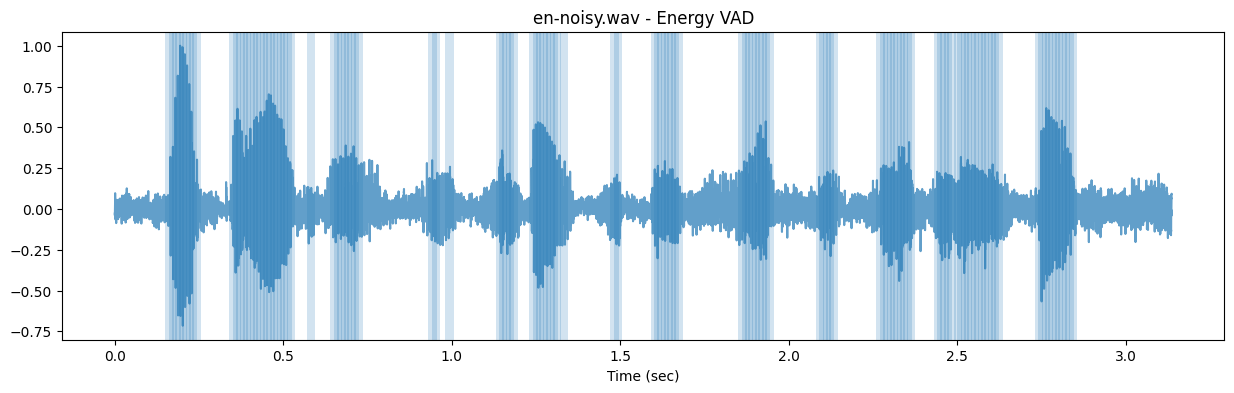

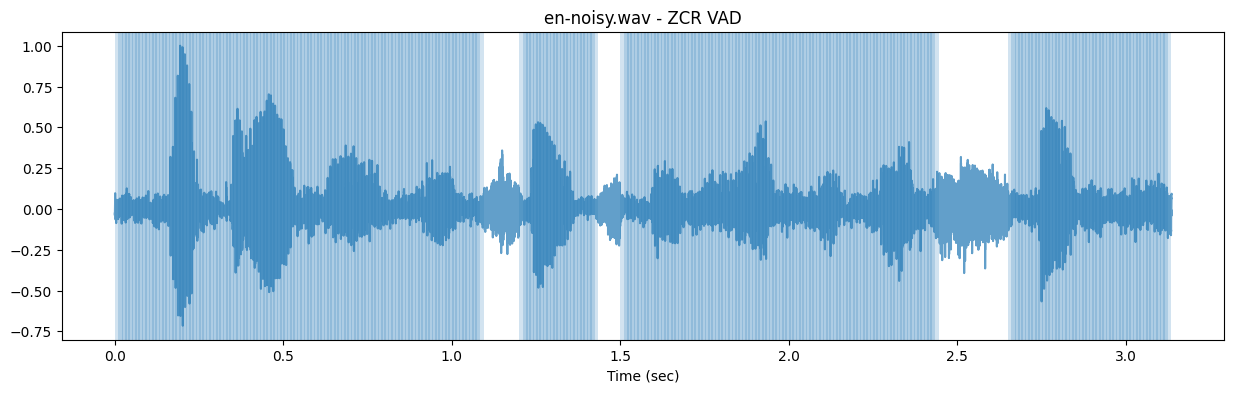

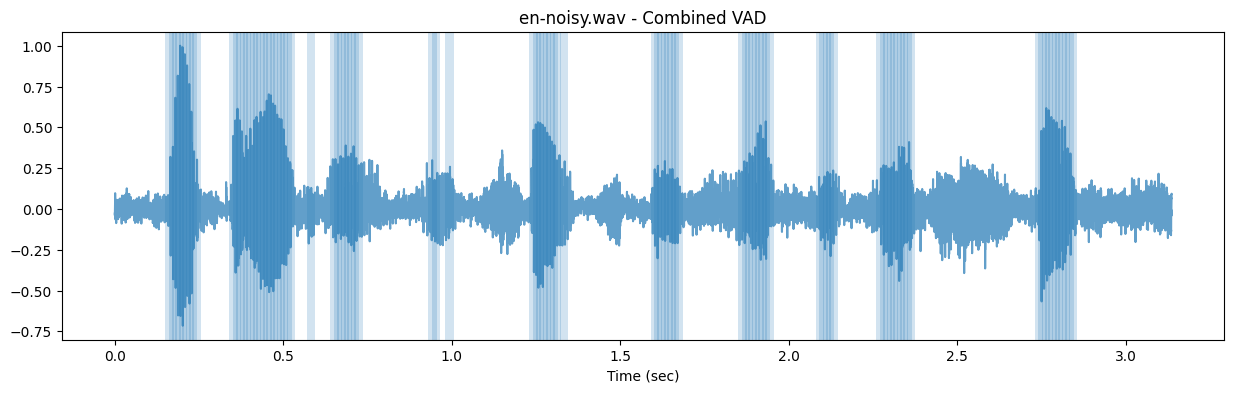

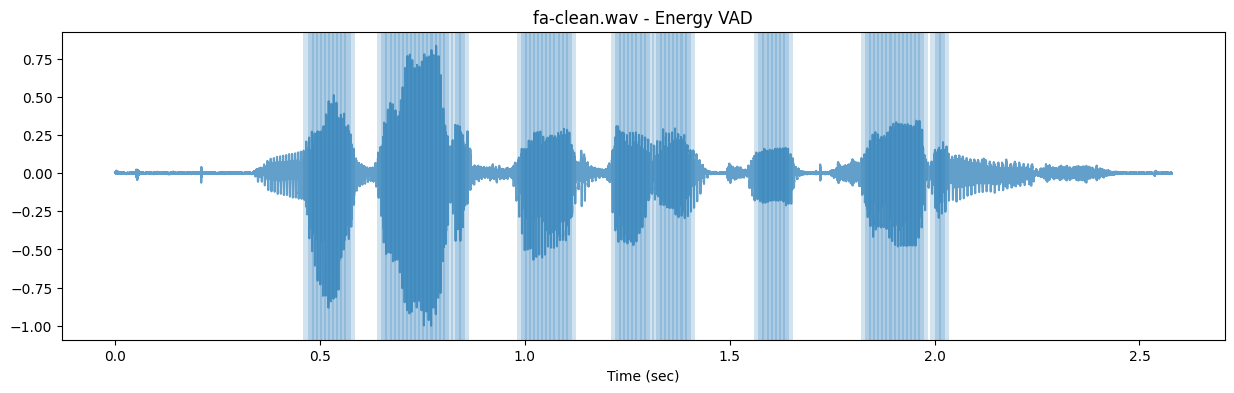

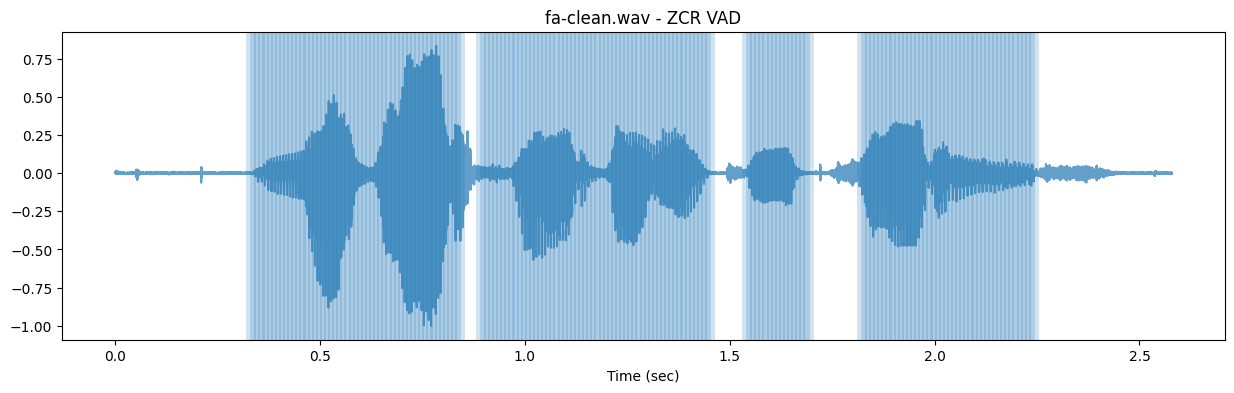

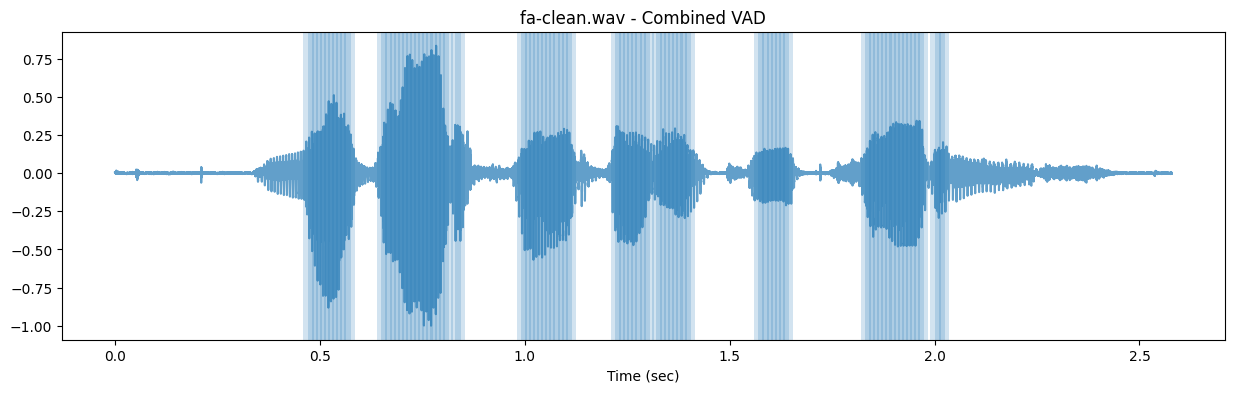

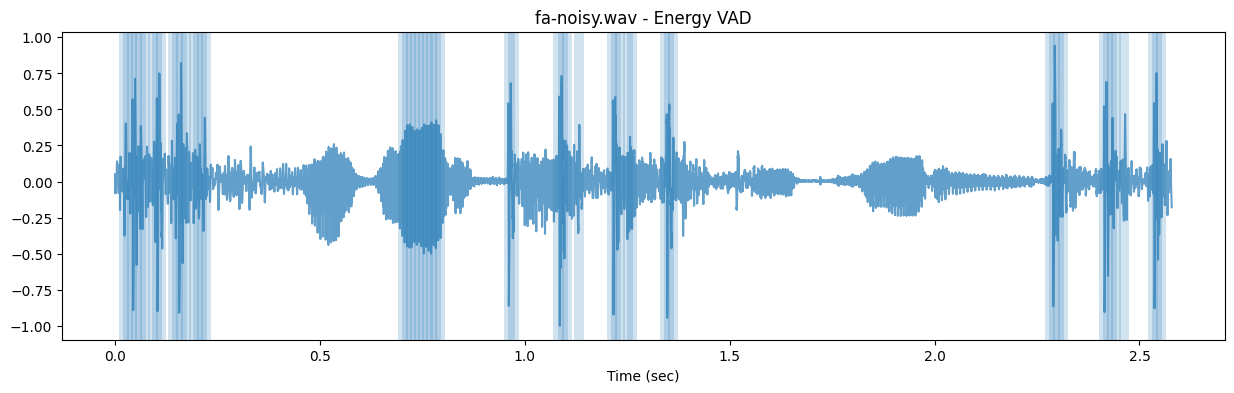

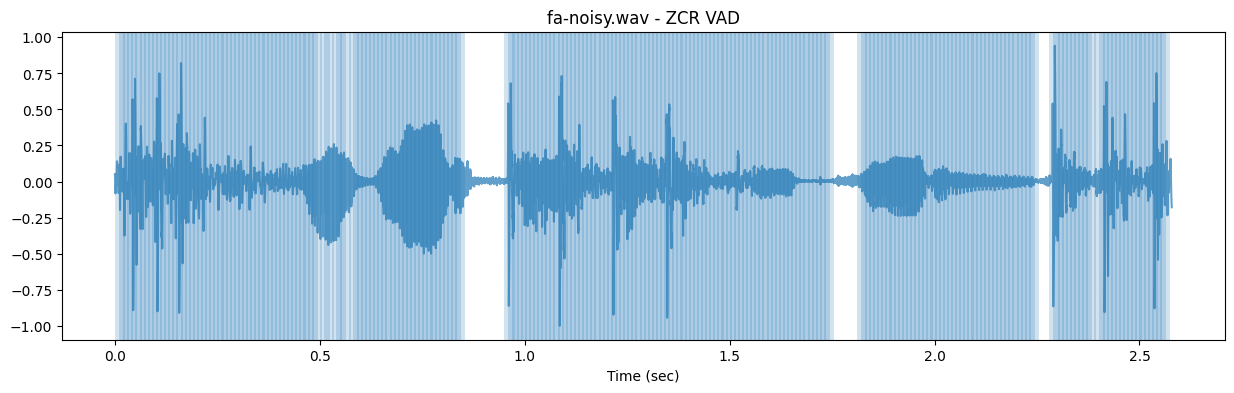

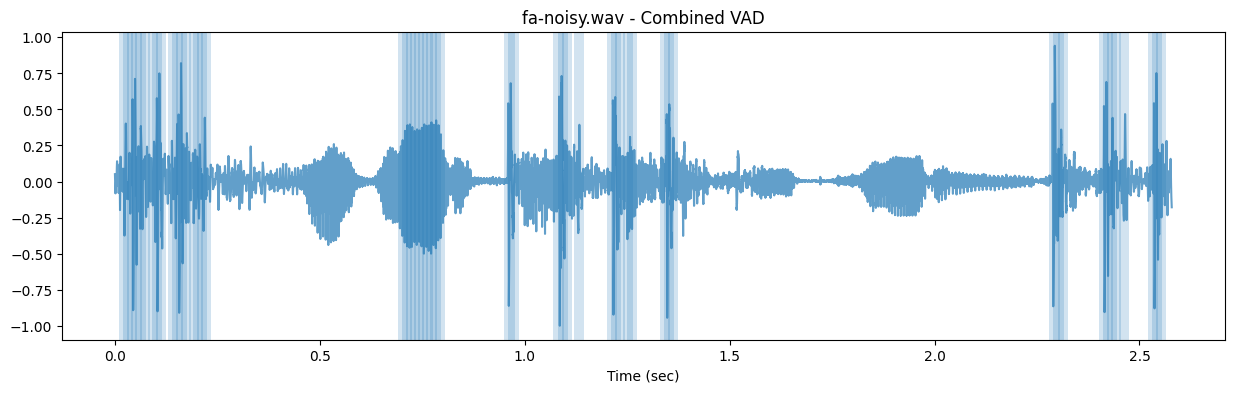

In [5]:
# ==================================
# Part 4 - Threshold-Based VAD
# ==================================

import numpy as np
import matplotlib.pyplot as plt


# -------------------------------------
# Initial thresholds
# (can be tuned later)
# -------------------------------------

ENERGY_THRESHOLD = 0.08
ZCR_THRESHOLD    = 0.35


def vad_energy(energy,
               threshold):
    """
    Energy-only speech detection.
    """
    return (energy > threshold).astype(int)


def vad_zcr(zcr,
            threshold):
    """
    ZCR-only speech detection.
    
    Lower ZCR often indicates speech.
    """
    return (zcr < threshold).astype(int)


def vad_combined(
    energy,
    zcr,
    energy_th,
    zcr_th
):
    """
    Combined decision rule.
    """

    speech_mask = (
        (energy > energy_th) &
        (zcr < zcr_th)
    )

    return speech_mask.astype(int)



# -------------------------------------
# Run VAD on all signals
# -------------------------------------

for file_name in audio_files:

    energy = energy_results[file_name]["energy"]
    zcr    = energy_results[file_name]["zcr"]

    energy_vad = vad_energy(
        energy,
        ENERGY_THRESHOLD
    )

    zcr_vad = vad_zcr(
        zcr,
        ZCR_THRESHOLD
    )

    combined_vad = vad_combined(
        energy,
        zcr,
        ENERGY_THRESHOLD,
        ZCR_THRESHOLD
    )

    energy_results[file_name]["vad_energy"] = energy_vad
    energy_results[file_name]["vad_zcr"] = zcr_vad
    energy_results[file_name]["vad_combined"] = combined_vad



# -------------------------------------
# Visualization
# Red regions show detected speech
# -------------------------------------

def plot_vad(signal,
             sr,
             vad_mask,
             title):

    hop_len = int(sr*HOP_SIZE_MS/1000)

    t = np.arange(len(signal))/sr

    plt.figure(figsize=(15,4))
    plt.plot(
        t,
        signal,
        alpha=0.7
    )

    # Mark speech frames
    for i, speech in enumerate(vad_mask):

        if speech:

            start = i*hop_len/sr
            end   = start + FRAME_SIZE_MS/1000

            plt.axvspan(
                start,
                end,
                alpha=0.2
            )

    plt.title(title)
    plt.xlabel("Time (sec)")
    plt.show()



# -------------------------------------
# Show all 3 methods
# -------------------------------------

for file_name in audio_files:

    signal = audio_data[file_name]["signal"]
    sr     = audio_data[file_name]["sr"]


    plot_vad(
        signal,
        sr,
        energy_results[file_name]["vad_energy"],
        f"{file_name} - Energy VAD"
    )


    plot_vad(
        signal,
        sr,
        energy_results[file_name]["vad_zcr"],
        f"{file_name} - ZCR VAD"
    )


    plot_vad(
        signal,
        sr,
        energy_results[file_name]["vad_combined"],
        f"{file_name} - Combined VAD"
    )